**Weather conditions mapping**

weather_conditions :

    0: "Clear Sky ☀️"

    1: "Mainly Clear 🌤"

    2: "Partly Cloudy ⛅"

    3: "Cloudy ☁️"

    45: "Fog 🌫"

    48: "Fog 🌫"

    51: "Light Drizzle 🌦"

    53: "Moderate Drizzle 🌧"

    55: "Heavy Drizzle 🌧"

    61: "Light Rain 🌦"

    63: "Moderate Rain 🌧"

    65: "Heavy Rain 🌧"

    71: "Light Snow ❄️"

    73: "Moderate Snow ❄️"

    75: "Heavy Snow ❄️"

    95: "Thunderstorm ⛈"


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from datetime import timedelta
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import spearmanr, pearsonr

# **Step 1: Understand the dataset**

**1. Identify the number of samples, features and labels**

In [ ]:
data = pd.read_csv("monastir_data_version3.csv")
data.head()

,date,weather_code,temperature_2m_max (°C),temperature_2m_min (°C),daylight_duration (s),sunshine_duration (s),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),...,surface_pressure_max (hPa),surface_pressure_min (hPa),visibility_min (undefined),visibility_max (undefined),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),wet_bulb_temperature_2m_min (°C),wet_bulb_temperature_2m_max (°C),soil_moisture_0_to_100cm_mean (m³/m³),soil_temperature_0_to_100cm_mean (°C)
0,2000-01-01,51,11.4,5.0,35205.09,31503.34,1.9,8.0,14.8,28.8,...,1021.5,1019.3,NaN,NaN,16.2,8.6,3.4,7.3,0.234,13.0
1,2000-01-02,51,12.7,6.3,35240.28,29380.86,0.3,1.0,22.9,39.2,...,1023.6,1021.2,NaN,NaN,20.2,11.7,4.7,7.5,0.235,12.9
2,2000-01-03,53,12.4,7.4,35278.86,31600.02,2.5,6.0,23.2,44.6,...,1024.9,1022.7,NaN,NaN,19.4,10.7,5.3,8.7,0.235,12.9
3,2000-01-04,3,13.7,8.4,35320.75,31651.05,0.0,0.0,16.1,29.9,...,1026.3,1023.9,NaN,NaN,14.0,9.7,5.1,8.1,0.236,12.9
4,2000-01-05,2,14.1,5.0,35365.83,31703.68,0.0,0.0,12.0,24.8,...,1024.7,1020.5,NaN,NaN,8.6,5.7,3.9,9.5,0.234,12.7


In [3]:
print(len(data))

9252


Our dataset contains 9252 row with 31 column inclusing the date and the target 

**2. Check the data types**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9252 entries, 0 to 9251
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   date                                   9252 non-null   object 
 1   weather_code                           9252 non-null   int64  
 2   temperature_2m_max (°C)                9252 non-null   float64
 3   temperature_2m_min (°C)                9252 non-null   float64
 4   daylight_duration (s)                  9252 non-null   float64
 5   sunshine_duration (s)                  9252 non-null   float64
 6   rain_sum (mm)                          9252 non-null   float64
 7   precipitation_hours (h)                9252 non-null   float64
 8   wind_speed_10m_max (km/h)              9252 non-null   float64
 9   wind_gusts_10m_max (km/h)              9252 non-null   float64
 10  cape_max (undefined)                   0 non-null      float64
 11  cape

After printing the data info, we can conclude that we have 2 main problems:

- The first problem is the type of the date feature ( It's object instead of date_time )

- The second problem is that we have 4 NaN features ( visibility_min (undefined), visibility_max (undefined), cape_max (undefined), cape_min (undefined) )

**3. Fix the date type**

Convert the date type from object to date_time

In [5]:
data['date'] = pd.to_datetime(data['date'])

**4. Extract useful time-based features (day, month, year)**

In [6]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

Now , it remains only one problem. We will fix the problem of the NaN values in the 4 features by droping them completely from the dataframe because they are empty

**5. Droping the visibilty_min , the visibility_max, cape_min, cape_max**

**Why??** Beacuse they are empty ( thier values weren't saved )

In [7]:
data.drop(['cape_max (undefined)', 'cape_min (undefined)', 'visibility_min (undefined)', 'visibility_max (undefined)'], axis=1, inplace=True)


**6. Map the weather_code to his condition for better understanding**

In [8]:
# Create the mapping dictionary
weather_conditions = {
    0: "Clear Sky ☀️",
    1: "Mainly Clear 🌤",
    2: "Partly Cloudy ⛅",
    3: "Cloudy ☁️",
    45: "Fog 🌫",
    48: "Fog 🌫",
    51: "Light Drizzle 🌦",
    53: "Moderate Drizzle 🌧",
    55: "Heavy Drizzle 🌧",
    61: "Light Rain 🌦",
    63: "Moderate Rain 🌧",
    65: "Heavy Rain 🌧",
    71: "Light Snow ❄️",
    73: "Moderate Snow ❄️",
    75: "Heavy Snow ❄️",
    95: "Thunderstorm ⛈"
}

# Apply the mapping to create a new column
data['weather_condition'] = data['weather_code'].map(weather_conditions)


**7. Droping the weather_code feature after creating the weather_condition feature (Target variable)**

**Why??** Because they are giving the same information but their type is different ( one is numerical and the other is categorical )

In [9]:
# Drop the weather_code column
data = data.drop(columns=['weather_code'])

**8. Reordering the Columns**

In [10]:
# List of columns in the desired order
new_column_order = [
       'date', 'year', 'month', 'day', 
       'temperature_2m_max (°C)','temperature_2m_min (°C)',
       'relative_humidity_2m_max (%)','relative_humidity_2m_min (%)',
       'daylight_duration (s)','sunshine_duration (s)',
       'cloud_cover_min (%)', 'cloud_cover_max (%)',
       'dew_point_2m_max (°C)','dew_point_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)',
       'wind_gusts_10m_min (km/h)','wind_speed_10m_min (km/h)', 
       'surface_pressure_max (hPa)','surface_pressure_min (hPa)', 
       'pressure_msl_max (hPa)','pressure_msl_min (hPa)',
       'wet_bulb_temperature_2m_max (°C)', 'wet_bulb_temperature_2m_min (°C)',
       'soil_moisture_0_to_100cm_mean (m³/m³)','soil_temperature_0_to_100cm_mean (°C)',
       'et0_fao_evapotranspiration_sum (mm)','weather_condition'
]
# Reorder the DataFrame columns
data = data[new_column_order]
data.head()

,date,year,month,day,temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_max (%),relative_humidity_2m_min (%),daylight_duration (s),sunshine_duration (s),...,surface_pressure_max (hPa),surface_pressure_min (hPa),pressure_msl_max (hPa),pressure_msl_min (hPa),wet_bulb_temperature_2m_max (°C),wet_bulb_temperature_2m_min (°C),soil_moisture_0_to_100cm_mean (m³/m³),soil_temperature_0_to_100cm_mean (°C),et0_fao_evapotranspiration_sum (mm),weather_condition
0,2000-01-01,2000,1,1,11.4,5.0,86,60,35205.09,31503.34,...,1021.5,1019.3,1025.1,1022.9,7.3,3.4,0.234,13.0,1.35,Light Drizzle 🌦
1,2000-01-02,2000,1,2,12.7,6.3,85,49,35240.28,29380.86,...,1023.6,1021.2,1027.2,1024.8,7.5,4.7,0.235,12.9,1.83,Light Drizzle 🌦
2,2000-01-03,2000,1,3,12.4,7.4,81,63,35278.86,31600.02,...,1024.9,1022.7,1028.5,1026.3,8.7,5.3,0.235,12.9,1.63,Moderate Drizzle 🌧
3,2000-01-04,2000,1,4,13.7,8.4,80,48,35320.75,31651.05,...,1026.3,1023.9,1029.9,1027.5,8.1,5.1,0.236,12.9,1.96,Cloudy ☁️
4,2000-01-05,2000,1,5,14.1,5.0,90,58,35365.83,31703.68,...,1024.7,1020.5,1028.3,1024.1,9.5,3.9,0.234,12.7,1.52,Partly Cloudy ⛅


# **Step 2: Perform Data Cleaning**

**1. Handle Missing Values**

In [11]:
data.isnull().sum()

date                                     0
year                                     0
month                                    0
day                                      0
temperature_2m_max (°C)                  0
temperature_2m_min (°C)                  0
relative_humidity_2m_max (%)             0
relative_humidity_2m_min (%)             0
daylight_duration (s)                    0
sunshine_duration (s)                    0
cloud_cover_min (%)                      0
cloud_cover_max (%)                      0
dew_point_2m_max (°C)                    0
dew_point_2m_min (°C)                    0
rain_sum (mm)                            0
precipitation_hours (h)                  0
wind_speed_10m_max (km/h)                0
wind_gusts_10m_max (km/h)                0
wind_gusts_10m_min (km/h)                0
wind_speed_10m_min (km/h)                0
surface_pressure_max (hPa)               0
surface_pressure_min (hPa)               0
pressure_msl_max (hPa)                   0
pressure_ms

We have no missing data in the dataset 

**2. Remove Duplicates**

In [12]:
print(data.duplicated().sum())

0


There is no duplicated rows in the data 

**3. Save the cleaned data**

In [14]:
data.to_csv('cleaned_weather_data_open_meteo_Monastir_final_version5.csv', index=False)

**=======>The first dataset has 9252 row and 31 variable including the target and the date ones.**

- The date column is not in date_time format (it's in object format), so we started by changing it into date_time format after that we extracted the year, month, and day from each date. 

- By printing the data information, we figured out that the visibility and the cape features ( 4 variables ) are always NaN ( No values saved in them ), so we droped them from our dataframe.

- After that, we decided to map each weather_code to its weather_condition ( creating new column called weather_condition ( categorical feature) ) and after that droping the weather_code feature.

         **Why did we decide to map the weather_code to its weather_condition ?** 
         
    First reason is the clairness of the target, and the second reason is to prepare it for the model ( because the weather_code has different values and they are not ordered , so changing them into categorical format and after that encoding them will be easier for the model to undersatnd and interpret)

         **Why did we decide to drop the weather_code after creating the weather_condition ?** 
    
    Because both of them has the same meaning but one is numerical and the other one is categorical

- Checking for missing data, and duplicated one is another curcial step that we have taken and hopefully, we have no missing or duplicated data.


**=======>The Final dataset has 9252 row and 30 feature including the target (weather_condition) and the date with no missing or duplicated data.**



# **Step 3: Data Exploration (Understand Your Data)**

In [15]:
import pandas as pd
df=pd.read_csv("cleaned_weather_data_open_meteo_Monastir_final_version5.csv")
df.head()

,date,year,month,day,temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_max (%),relative_humidity_2m_min (%),daylight_duration (s),sunshine_duration (s),...,surface_pressure_max (hPa),surface_pressure_min (hPa),pressure_msl_max (hPa),pressure_msl_min (hPa),wet_bulb_temperature_2m_max (°C),wet_bulb_temperature_2m_min (°C),soil_moisture_0_to_100cm_mean (m³/m³),soil_temperature_0_to_100cm_mean (°C),et0_fao_evapotranspiration_sum (mm),weather_condition
0,2000-01-01,2000,1,1,11.4,5.0,86,60,35205.09,31503.34,...,1021.5,1019.3,1025.1,1022.9,7.3,3.4,0.234,13.0,1.35,Light Drizzle 🌦
1,2000-01-02,2000,1,2,12.7,6.3,85,49,35240.28,29380.86,...,1023.6,1021.2,1027.2,1024.8,7.5,4.7,0.235,12.9,1.83,Light Drizzle 🌦
2,2000-01-03,2000,1,3,12.4,7.4,81,63,35278.86,31600.02,...,1024.9,1022.7,1028.5,1026.3,8.7,5.3,0.235,12.9,1.63,Moderate Drizzle 🌧
3,2000-01-04,2000,1,4,13.7,8.4,80,48,35320.75,31651.05,...,1026.3,1023.9,1029.9,1027.5,8.1,5.1,0.236,12.9,1.96,Cloudy ☁️
4,2000-01-05,2000,1,5,14.1,5.0,90,58,35365.83,31703.68,...,1024.7,1020.5,1028.3,1024.1,9.5,3.9,0.234,12.7,1.52,Partly Cloudy ⛅


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9252 entries, 0 to 9251
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   date                                   9252 non-null   object 
 1   year                                   9252 non-null   int64  
 2   month                                  9252 non-null   int64  
 3   day                                    9252 non-null   int64  
 4   temperature_2m_max (°C)                9252 non-null   float64
 5   temperature_2m_min (°C)                9252 non-null   float64
 6   relative_humidity_2m_max (%)           9252 non-null   int64  
 7   relative_humidity_2m_min (%)           9252 non-null   int64  
 8   daylight_duration (s)                  9252 non-null   float64
 9   sunshine_duration (s)                  9252 non-null   float64
 10  cloud_cover_min (%)                    9252 non-null   int64  
 11  clou

**1. Visualize the distribution of the features**

**a. Using Histograms**

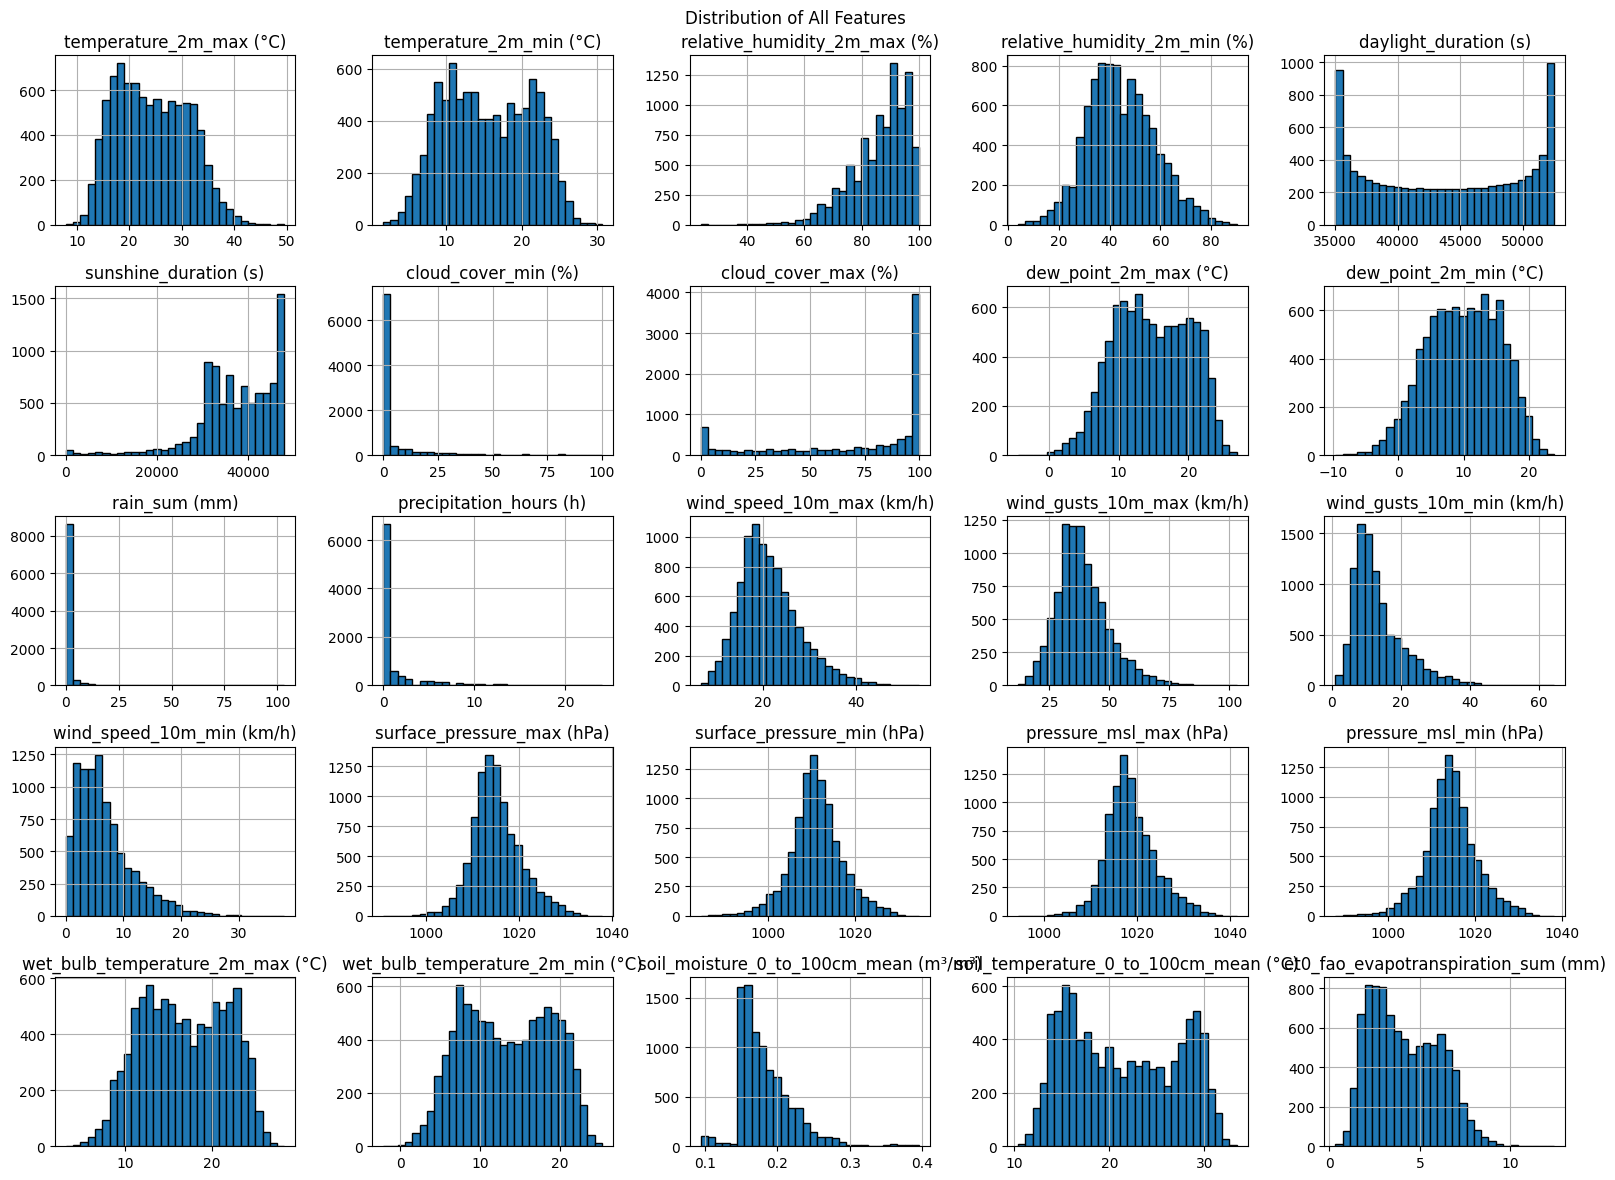

In [17]:
import matplotlib.pyplot as plt
# Create a copy of the original dataframe
data1 = df.copy()
# Plot histograms for all numerical features
data1.drop(columns=["date", "year", "month", "day", "weather_condition"], inplace=True) 
data1.hist(bins=30, figsize=(16, 12), edgecolor='black')
plt.suptitle('Distribution of All Features')
plt.tight_layout()
plt.show()


Using the histograms to visualize the disribution of the variables to conclude if we can delete the varibales that has no changement over time.
 There is no constant variable in the data. So, there is no action to take after ploting thier distribution

**b. Correlation Analysis Between Features Using Heatmap**

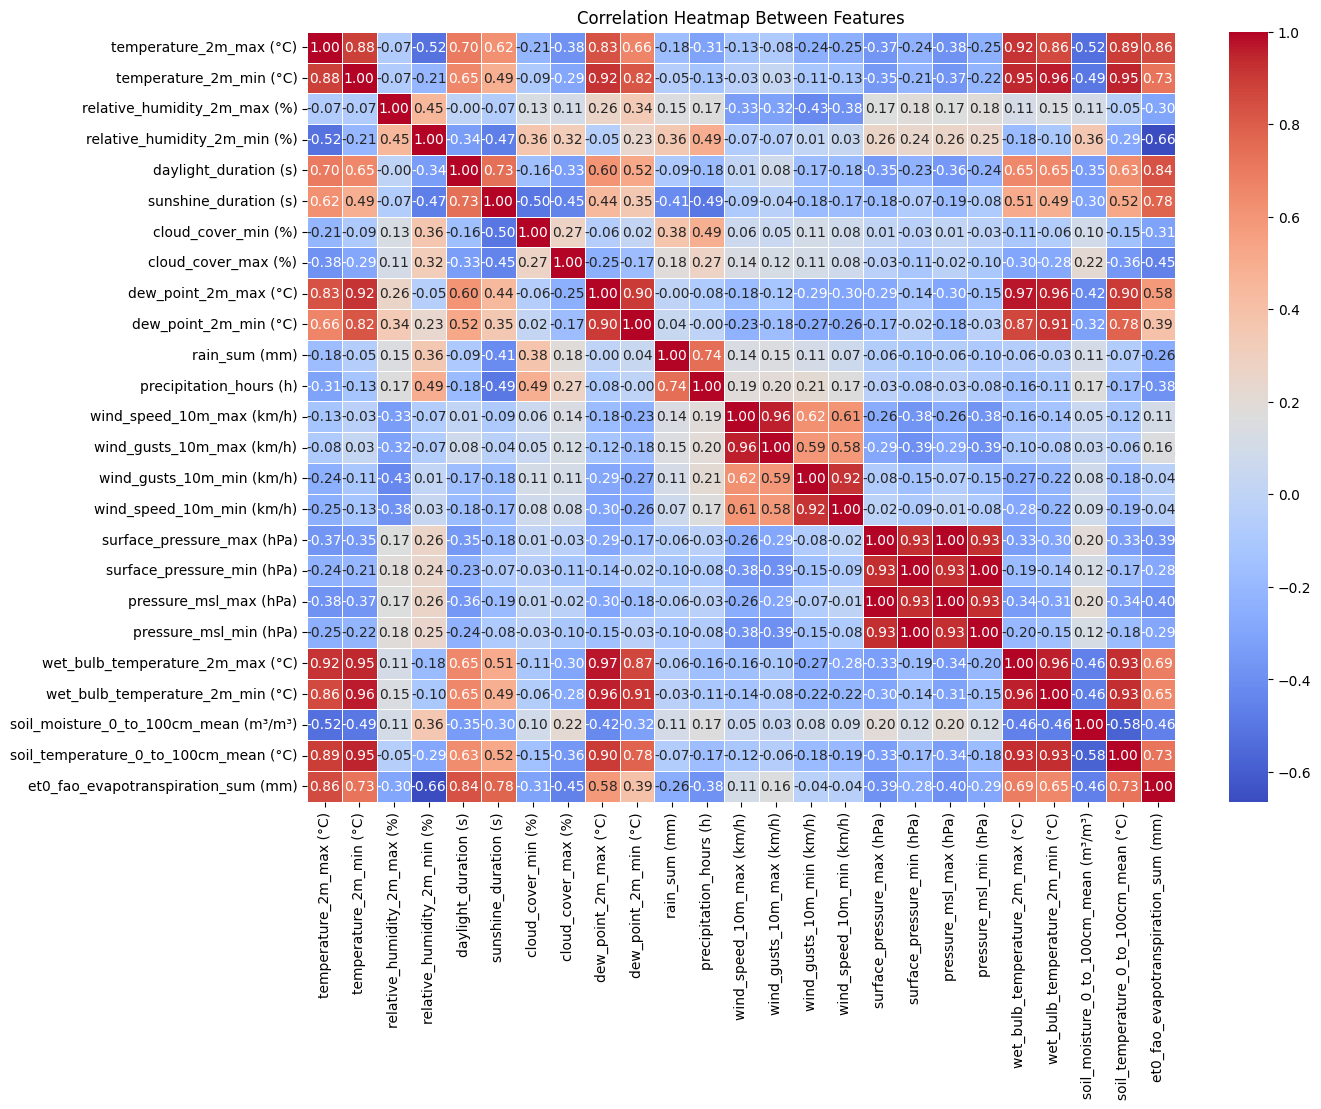

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix = data1.corr()

# Display heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Between Features")
plt.show()

- We can interpret that the wet_bulb_temperature_min is highly correlated with 5 other features.

- We can also see that the wet_bulb_temperature_max is highly correlated with 5 features

- We can also conclude that the soil_temperature_0_to_100cm_mean is also highly correlated with 4 other features

- As it's shown in the heatmap too, the dewpoint_max is highly correlated with 5 features

- The pressure_msl features and the surface pressure features are highly correlated 


**c. Max Temperature vs Rainfall by Weather Condition Using Scatterplots**

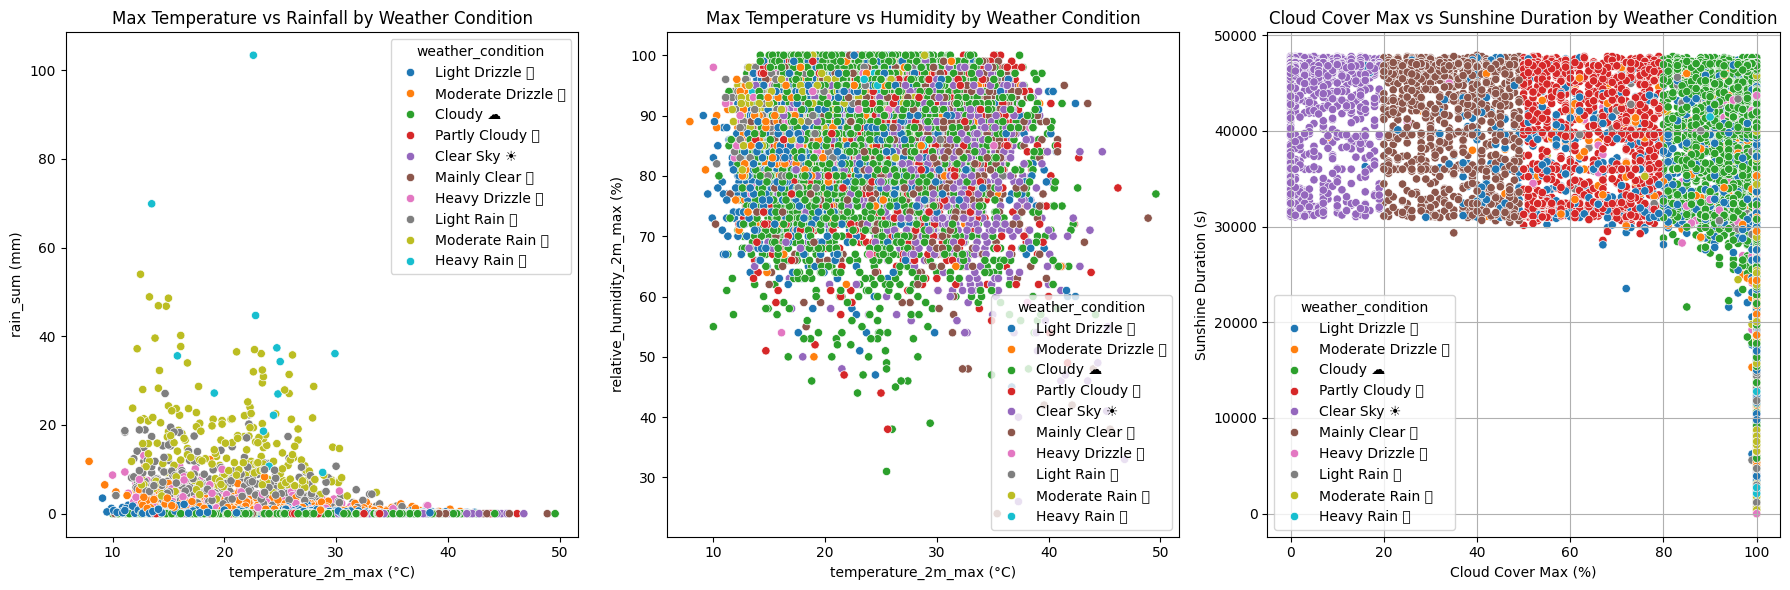

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure and axes
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Scatterplot 1: Max Temperature vs Rainfall by Weather Condition
sns.scatterplot(
    data=df, 
    x='temperature_2m_max (°C)', 
    y='rain_sum (mm)', 
    hue='weather_condition',
    palette='tab10',
    ax=axs[0]
)
axs[0].set_title('Max Temperature vs Rainfall by Weather Condition')

# Scatterplot 2: Max Temperature vs Humidity by Weather Condition
sns.scatterplot(
    data=df, 
    x='temperature_2m_max (°C)', 
    y='relative_humidity_2m_max (%)', 
    hue='weather_condition',
    palette='tab10',
    ax=axs[1]
)
axs[1].set_title('Max Temperature vs Humidity by Weather Condition')

# Scatterplot 3: Cloud Cover Max vs Sunshine Duration by Weather Condition
sns.scatterplot(
    data=df,
    x='cloud_cover_max (%)',
    y='sunshine_duration (s)',
    hue='weather_condition',
    palette='tab10',
    ax=axs[2]
)
axs[2].set_title('Cloud Cover Max vs Sunshine Duration by Weather Condition')
axs[2].set_xlabel('Cloud Cover Max (%)')
axs[2].set_ylabel('Sunshine Duration (s)')
axs[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


- The scatter plots illustrate the relationship between two different variables, helping us understand how they influence the weather condition.

**e. Average for each feature by month Using barplots**

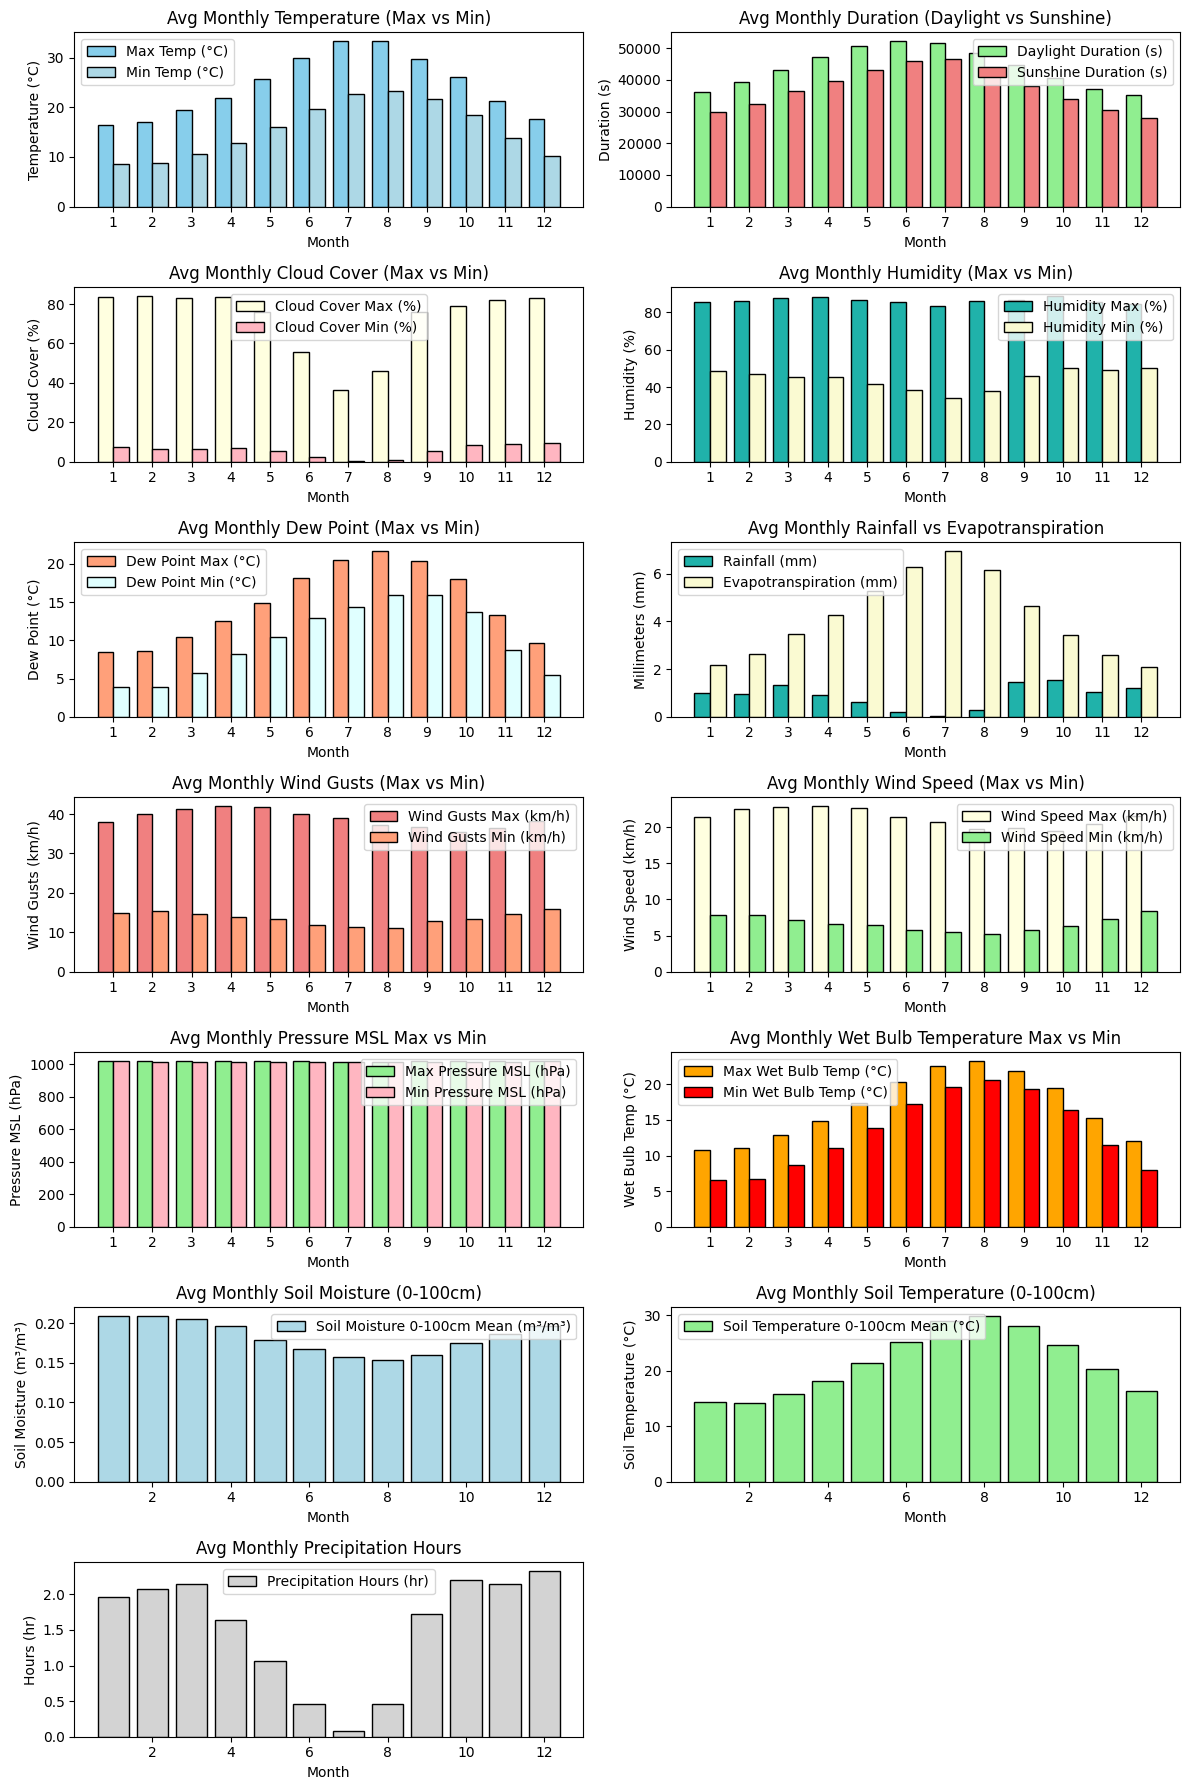

In [ ]:
# Calculate the average for each feature by month using the remaining columns
monthly_avg_temp_max = df.groupby('month')['temperature_2m_max (°C)'].mean()
monthly_avg_temp_min = df.groupby('month')['temperature_2m_min (°C)'].mean()
monthly_avg_daylight = df.groupby('month')['daylight_duration (s)'].mean()
monthly_avg_sunshine = df.groupby('month')['sunshine_duration (s)'].mean()
monthly_avg_cloud_cover_max = df.groupby('month')['cloud_cover_max (%)'].mean()
monthly_avg_cloud_cover_min = df.groupby('month')['cloud_cover_min (%)'].mean()
monthly_avg_relative_humidity_max = df.groupby('month')['relative_humidity_2m_max (%)'].mean()
monthly_avg_relative_humidity_min = df.groupby('month')['relative_humidity_2m_min (%)'].mean()
monthly_avg_dew_point_max = df.groupby('month')['dew_point_2m_max (°C)'].mean()
monthly_avg_dew_point_min = df.groupby('month')['dew_point_2m_min (°C)'].mean()
monthly_avg_rain = df.groupby('month')['rain_sum (mm)'].mean()
monthly_avg_et0_fao_evapotranspiration_sum = df.groupby('month')['et0_fao_evapotranspiration_sum (mm)'].mean()
monthly_avg_wind_gusts_max = df.groupby('month')['wind_gusts_10m_max (km/h)'].mean()
monthly_avg_wind_gusts_min = df.groupby('month')['wind_gusts_10m_min (km/h)'].mean()
monthly_avg_wind_speed_max = df.groupby('month')['wind_speed_10m_max (km/h)'].mean()
monthly_avg_wind_speed_min = df.groupby('month')['wind_speed_10m_min (km/h)'].mean()
monthly_avg_surface_pressure_max = df.groupby('month')['surface_pressure_max (hPa)'].mean()
monthly_avg_surface_pressure_min = df.groupby('month')['surface_pressure_min (hPa)'].mean()
monthly_avg_pressure_msl_max = df.groupby('month')['pressure_msl_max (hPa)'].mean()
monthly_avg_pressure_msl_min = df.groupby('month')['pressure_msl_min (hPa)'].mean()
monthly_avg_wet_bulb_temperature_2m_max = df.groupby('month')['wet_bulb_temperature_2m_max (°C)'].mean()
monthly_avg_wet_bulb_temperature_2m_min = df.groupby('month')['wet_bulb_temperature_2m_min (°C)'].mean()
monthly_avg_soil_moisture_0_to_100cm_mean = df.groupby('month')['soil_moisture_0_to_100cm_mean (m³/m³)'].mean()
monthly_avg_soil_temperature_0_to_100cm_mean = df.groupby('month')['soil_temperature_0_to_100cm_mean (°C)'].mean()
monthly_avg_precipitation_hours = df.groupby('month')['precipitation_hours (h)'].mean()

# Create a grid of 7 rows and 2 columns for the subplots (13 plots total)
fig, axs = plt.subplots(7, 2, figsize=(12, 18))  # 7 rows, 2 columns

# Temperature Max vs Min
x = np.arange(len(monthly_avg_temp_max))  # numerical positions for each month
bar_width = 0.4

axs[0, 0].bar(x - bar_width/2, monthly_avg_temp_max, width=bar_width,
              color='skyblue', edgecolor='black', label='Max Temp (°C)')
axs[0, 0].bar(x + bar_width/2, monthly_avg_temp_min, width=bar_width,
              color='lightblue', edgecolor='black', label='Min Temp (°C)')

axs[0, 0].set_title('Avg Monthly Temperature (Max vs Min)')
axs[0, 0].set_xlabel('Month')
axs[0, 0].set_ylabel('Temperature (°C)')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(monthly_avg_temp_max.index)
axs[0, 0].legend()

# Daylight Duration vs Sunshine Duration
x = np.arange(len(monthly_avg_daylight)) 
bar_width = 0.4

axs[0, 1].bar(x - bar_width/2, monthly_avg_daylight, width=bar_width,
              color='lightgreen', edgecolor='black', label='Daylight Duration (s)')
axs[0, 1].bar(x + bar_width/2, monthly_avg_sunshine, width=bar_width,
              color='lightcoral', edgecolor='black', label='Sunshine Duration (s)')

axs[0, 1].set_title('Avg Monthly Duration (Daylight vs Sunshine)')
axs[0, 1].set_xlabel('Month')
axs[0, 1].set_ylabel('Duration (s)')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(monthly_avg_daylight.index)
axs[0, 1].legend()

# Cloud Cover Max vs Min
x = np.arange(len(monthly_avg_cloud_cover_max)) 
bar_width = 0.4

axs[1, 0].bar(x - bar_width/2, monthly_avg_cloud_cover_max, width=bar_width,
              color='lightyellow', edgecolor='black', label='Cloud Cover Max (%)')
axs[1, 0].bar(x + bar_width/2, monthly_avg_cloud_cover_min, width=bar_width,
              color='lightpink', edgecolor='black', label='Cloud Cover Min (%)')

axs[1, 0].set_title('Avg Monthly Cloud Cover (Max vs Min)')
axs[1, 0].set_xlabel('Month')
axs[1, 0].set_ylabel('Cloud Cover (%)')
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(monthly_avg_cloud_cover_max.index)
axs[1, 0].legend()

# Humidity Max vs Min
x = np.arange(len(monthly_avg_relative_humidity_max))  
bar_width = 0.4

axs[1, 1].bar(x - bar_width/2, monthly_avg_relative_humidity_max, width=bar_width,
              color='lightseagreen', edgecolor='black', label='Humidity Max (%)')
axs[1, 1].bar(x + bar_width/2, monthly_avg_relative_humidity_min, width=bar_width,
              color='lightgoldenrodyellow', edgecolor='black', label='Humidity Min (%)')

axs[1, 1].set_title('Avg Monthly Humidity (Max vs Min)')
axs[1, 1].set_xlabel('Month')
axs[1, 1].set_ylabel('Humidity (%)')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(monthly_avg_relative_humidity_max.index)
axs[1, 1].legend()


# Dew Point Max vs Min
x = np.arange(len(monthly_avg_dew_point_max))  
bar_width = 0.4

axs[2, 0].bar(x - bar_width/2, monthly_avg_dew_point_max, width=bar_width,
              color='lightsalmon', edgecolor='black', label='Dew Point Max (°C)')
axs[2, 0].bar(x + bar_width/2, monthly_avg_dew_point_min, width=bar_width,
              color='lightcyan', edgecolor='black', label='Dew Point Min (°C)')

axs[2, 0].set_title('Avg Monthly Dew Point (Max vs Min)')
axs[2, 0].set_xlabel('Month')
axs[2, 0].set_ylabel('Dew Point (°C)')
axs[2, 0].set_xticks(x)
axs[2, 0].set_xticklabels(monthly_avg_dew_point_max.index)
axs[2, 0].legend()


# Rain vs Evapotranspiration
x = np.arange(len(monthly_avg_rain)) 
bar_width = 0.4

axs[2, 1].bar(x - bar_width/2, monthly_avg_rain, width=bar_width,
              color='lightseagreen', edgecolor='black', label='Rainfall (mm)')
axs[2, 1].bar(x + bar_width/2, monthly_avg_et0_fao_evapotranspiration_sum, width=bar_width,
              color='lightgoldenrodyellow', edgecolor='black', label='Evapotranspiration (mm)')

axs[2, 1].set_title('Avg Monthly Rainfall vs Evapotranspiration')
axs[2, 1].set_xlabel('Month')
axs[2, 1].set_ylabel('Millimeters (mm)')
axs[2, 1].set_xticks(x)
axs[2, 1].set_xticklabels(monthly_avg_rain.index)
axs[2, 1].legend()

# Wind Gusts Max vs Min
x = np.arange(len(monthly_avg_wind_gusts_max))  
bar_width = 0.4

axs[3, 0].bar(x - bar_width/2, monthly_avg_wind_gusts_max, width=bar_width,
              color='lightcoral', edgecolor='black', label='Wind Gusts Max (km/h)')
axs[3, 0].bar(x + bar_width/2, monthly_avg_wind_gusts_min, width=bar_width,
              color='lightsalmon', edgecolor='black', label='Wind Gusts Min (km/h)')

axs[3, 0].set_title('Avg Monthly Wind Gusts (Max vs Min)')
axs[3, 0].set_xlabel('Month')
axs[3, 0].set_ylabel('Wind Gusts (km/h)')
axs[3, 0].set_xticks(x)
axs[3, 0].set_xticklabels(monthly_avg_wind_gusts_max.index)
axs[3, 0].legend()


# Wind Speed Max vs Min
x = np.arange(len(monthly_avg_wind_speed_max)) 
bar_width = 0.4

axs[3, 1].bar(x - bar_width/2, monthly_avg_wind_speed_max, width=bar_width,
              color='lightyellow', edgecolor='black', label='Wind Speed Max (km/h)')
axs[3, 1].bar(x + bar_width/2, monthly_avg_wind_speed_min, width=bar_width,
              color='lightgreen', edgecolor='black', label='Wind Speed Min (km/h)')

axs[3, 1].set_title('Avg Monthly Wind Speed (Max vs Min)')
axs[3, 1].set_xlabel('Month')
axs[3, 1].set_ylabel('Wind Speed (km/h)')
axs[3, 1].set_xticks(x)
axs[3, 1].set_xticklabels(monthly_avg_wind_speed_max.index)
axs[3, 1].legend()


# Pressure MSL Max vs Min

x = np.arange(len(monthly_avg_pressure_msl_max))  
bar_width = 0.4

axs[4, 0].bar(x - bar_width/2, monthly_avg_pressure_msl_max, width=bar_width,
              color='lightgreen', edgecolor='black', label='Max Pressure MSL (hPa)')
axs[4, 0].bar(x + bar_width/2, monthly_avg_pressure_msl_min, width=bar_width,
              color='lightpink', edgecolor='black', label='Min Pressure MSL (hPa)')

axs[4, 0].set_title('Avg Monthly Pressure MSL Max vs Min')
axs[4, 0].set_xlabel('Month')
axs[4, 0].set_ylabel('Pressure MSL (hPa)')
axs[4, 0].set_xticks(x)
axs[4, 0].set_xticklabels(monthly_avg_pressure_msl_max.index)
axs[4, 0].legend()

# Wet Bulb Temperature Max vs Min
x = np.arange(len(monthly_avg_wet_bulb_temperature_2m_max))  
bar_width = 0.4

axs[4, 1].bar(x - bar_width/2, monthly_avg_wet_bulb_temperature_2m_max, width=bar_width,
              color='orange', edgecolor='black', label='Max Wet Bulb Temp (°C)')
axs[4, 1].bar(x + bar_width/2, monthly_avg_wet_bulb_temperature_2m_min, width=bar_width,
              color='red', edgecolor='black', label='Min Wet Bulb Temp (°C)')

axs[4, 1].set_title('Avg Monthly Wet Bulb Temperature Max vs Min')
axs[4, 1].set_xlabel('Month')
axs[4, 1].set_ylabel('Wet Bulb Temp (°C)')
axs[4, 1].set_xticks(x)
axs[4, 1].set_xticklabels(monthly_avg_wet_bulb_temperature_2m_max.index)
axs[4, 1].legend()


# Soil Moisture 0-100cm Mean
axs[5, 0].bar(monthly_avg_soil_moisture_0_to_100cm_mean.index, monthly_avg_soil_moisture_0_to_100cm_mean, 
             color='lightblue', edgecolor='black', label='Soil Moisture 0-100cm Mean (m³/m³)')
axs[5, 0].set_title('Avg Monthly Soil Moisture (0-100cm)')
axs[5, 0].set_xlabel('Month')
axs[5, 0].set_ylabel('Soil Moisture (m³/m³)')
axs[5, 0].legend()

# Soil Temperature 0-100cm Mean
axs[5, 1].bar(monthly_avg_soil_temperature_0_to_100cm_mean.index, monthly_avg_soil_temperature_0_to_100cm_mean, 
              color='lightgreen', edgecolor='black', label='Soil Temperature 0-100cm Mean (°C)')
axs[5, 1].set_title('Avg Monthly Soil Temperature (0-100cm)')
axs[5, 1].set_xlabel('Month')
axs[5, 1].set_ylabel('Soil Temperature (°C)')
axs[5, 1].legend()

# Precipitation Hours 
axs[6, 0].bar(monthly_avg_precipitation_hours.index, monthly_avg_precipitation_hours, color='lightgrey', edgecolor='black', label='Precipitation Hours (hr)')
axs[6, 0].set_title('Avg Monthly Precipitation Hours')
axs[6, 0].set_xlabel('Month')
axs[6, 0].set_ylabel('Hours (hr)')
axs[6, 0].legend()

# Remove empty subplot at (6, 1)
fig.delaxes(axs[6, 1])

# Adjust layout for tight spacing
plt.tight_layout()
plt.show()


- The bar plots compare how each pair of related variables varies across months, allowing us to interpret their monthly distribution patterns.

**2. Visualize the Distibution of the target variable**

**a. Weather_condition distribution using the countplot**

Weather Condition Counts:
Cloudy ☁️: 3403
Light Drizzle 🌦: 1347
Clear Sky ☀️: 1251
Partly Cloudy ⛅: 1035
Mainly Clear 🌤: 963
Moderate Drizzle 🌧: 522
Light Rain 🌦: 330
Moderate Rain 🌧: 218
Heavy Drizzle 🌧: 170
Heavy Rain 🌧: 13


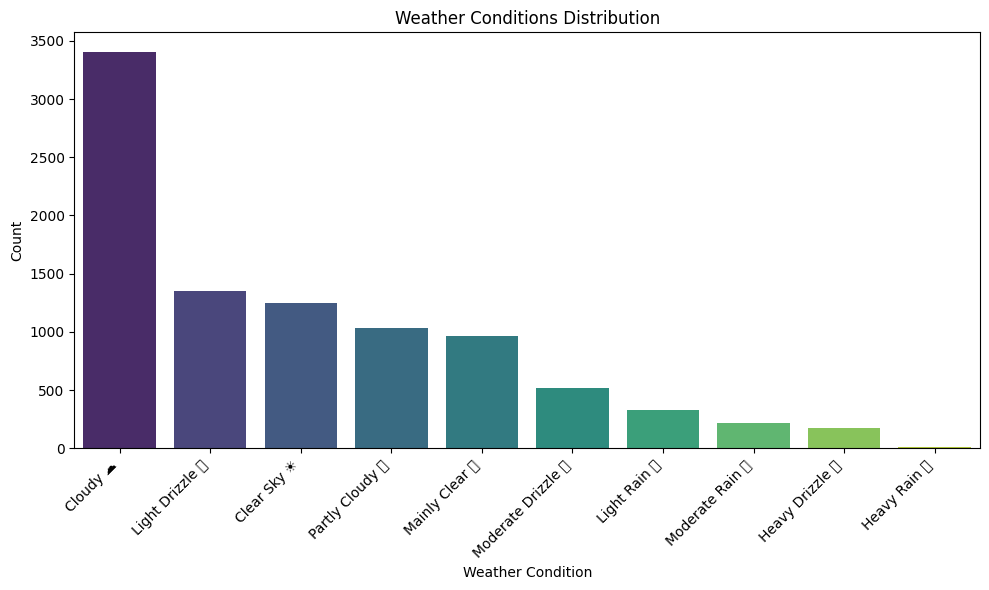

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

weather_counts = df['weather_condition'].value_counts()
print("Weather Condition Counts:")
for condition, count in weather_counts.items():
    print(f'{condition}: {count}')


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='weather_condition', order=df['weather_condition'].value_counts().index, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title('Weather Conditions Distribution')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


- This bar plot shows us that the target variable (weather_condition) is not balanced. 

- Our purpose is to predict weither it's going to be rainy, sunny etc so it's a classification problem. 

- That's why we can not work with imbalanced classes. 

**b. Weather_condition Distribution Per Month Using Bar Plot**

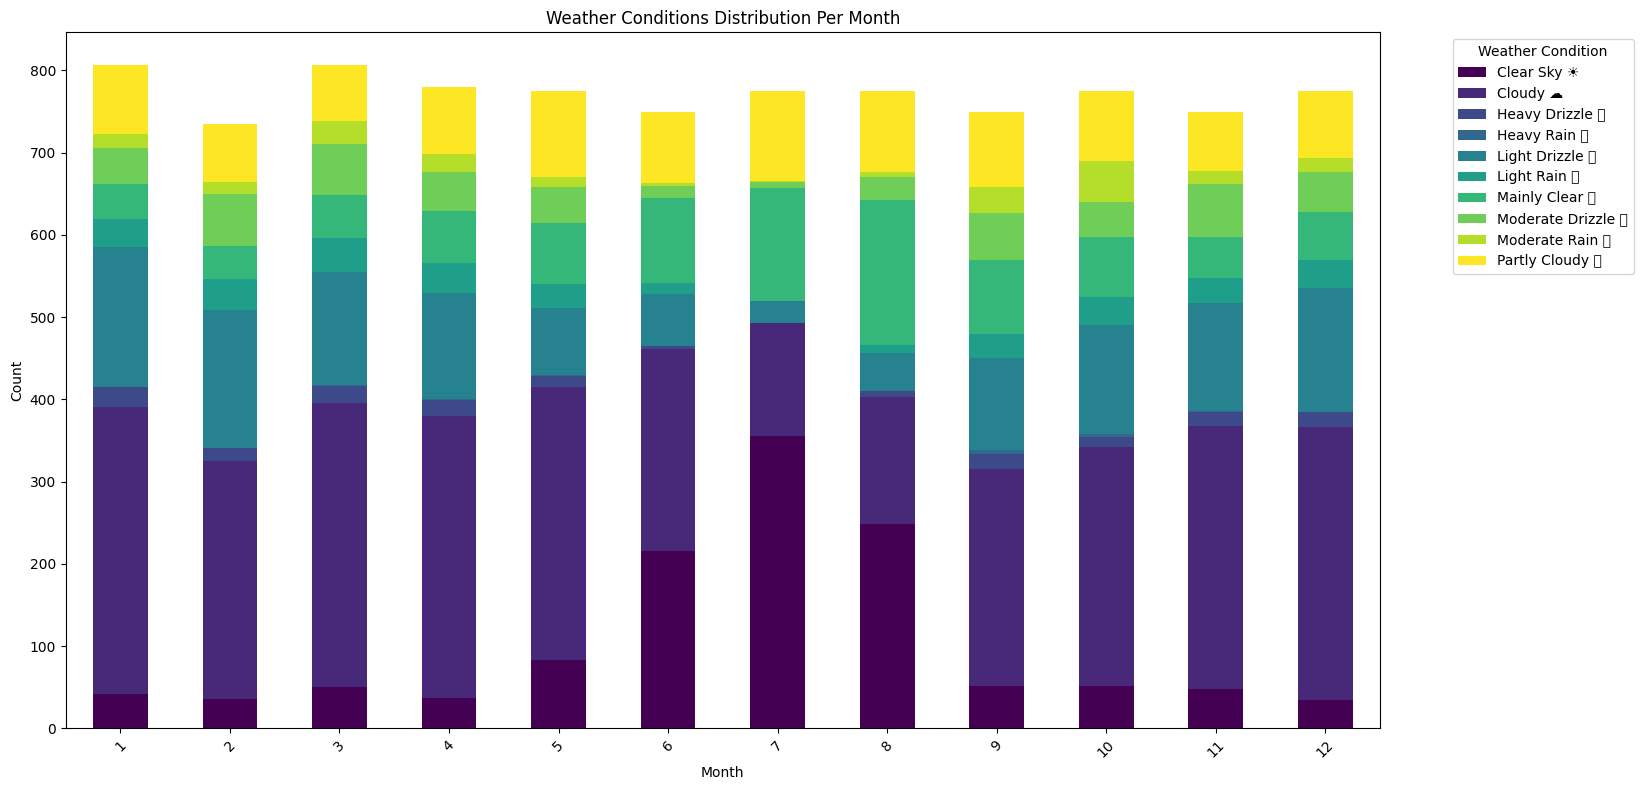

In [22]:
# Count how many times each weather condition appears per month
weather_counts_per_month = df.groupby(['month', 'weather_condition']).size().unstack(fill_value=0)

# Plotting the bar plot for weather conditions per month
weather_counts_per_month.plot(kind='bar', figsize=(14, 8), stacked=True, colormap='viridis')

# Adding title and labels
plt.title('Weather Conditions Distribution Per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Weather Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**3. Visualize seasonal trends**

**a. Temperature trends : Max and Min**

**b. Humidity trends : Max and Min**

# **Step 4: Feature Engineering (Creating New Features)**

In [23]:
import pandas as pd 
df1=pd.read_csv("cleaned_weather_data_open_meteo_Monastir_final_version5.csv")

**1. Create new features**

In [ ]:
import pandas as pd
import numpy as np

# 3. Temporal Features (Date-related features)
def create_temporal_features(df):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    # Basic calendar features
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofweek'] = df['date'].dt.dayofweek       # Monday=0, Sunday=6
    df['is_weekend'] = df['dayofweek'] >= 5         # Boolean flag
    
    # Seasonal encodings (sin/cos to handle cyclic nature)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    
    return df


# 4. Additional Features
def create_additional_features(df):
    # Temperature-related features
    df['temp_range'] = df['temperature_2m_max (°C)'] - df['temperature_2m_min (°C)']

    # Wind-related features
    df['wind_gust_range'] = df['wind_gusts_10m_max (km/h)'] - df['wind_gusts_10m_min (km/h)']
    df['avg_wind_speed'] = (df['wind_speed_10m_max (km/h)'] + df['wind_speed_10m_min (km/h)']) / 2
    df['wind_variability'] = df['wind_speed_10m_max (km/h)'] - df['wind_speed_10m_min (km/h)']

    # Humidity & Dew Point
    df['humidity_range'] = df['relative_humidity_2m_max (%)'] - df['relative_humidity_2m_min (%)']
    df['dew_point_range'] = df['dew_point_2m_max (°C)'] - df['dew_point_2m_min (°C)']

    # Cloud & Sun
    df['sunshine_ratio'] = df['sunshine_duration (s)'] / df['daylight_duration (s)']

    # Rain/Precipitation
    df['rain_today'] = df['rain_sum (mm)'].apply(lambda x: 1 if x > 0 else 0)

    # Pressure Features
    df['pressure_range'] = df['surface_pressure_max (hPa)'] - df['surface_pressure_min (hPa)']

    # 7. Daylight to Sunshine Ratio
    df['daylight_to_sunshine_ratio'] = df['daylight_duration (s)'] / (df['sunshine_duration (s)'] + 1)  

    # Fill missing values after creating new features
    df.ffill(inplace=True)

    return df

df1 = create_temporal_features(df1)  # Add temporal features
df1 = create_additional_features(df1)  # Add additional weather-related features


**2. Correlation Analysis of the new dataframe**

In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9252 entries, 0 to 9251
Data columns (total 47 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   date                                   9252 non-null   datetime64[ns]
 1   year                                   9252 non-null   int32         
 2   month                                  9252 non-null   int32         
 3   day                                    9252 non-null   int32         
 4   temperature_2m_max (°C)                9252 non-null   float64       
 5   temperature_2m_min (°C)                9252 non-null   float64       
 6   relative_humidity_2m_max (%)           9252 non-null   int64         
 7   relative_humidity_2m_min (%)           9252 non-null   int64         
 8   daylight_duration (s)                  9252 non-null   float64       
 9   sunshine_duration (s)                  9252 non-null   float64 

In [ ]:
data2 = df1.copy()
data2.drop(columns=["date", "year", "month", "day", "weather_condition"], inplace=True) 

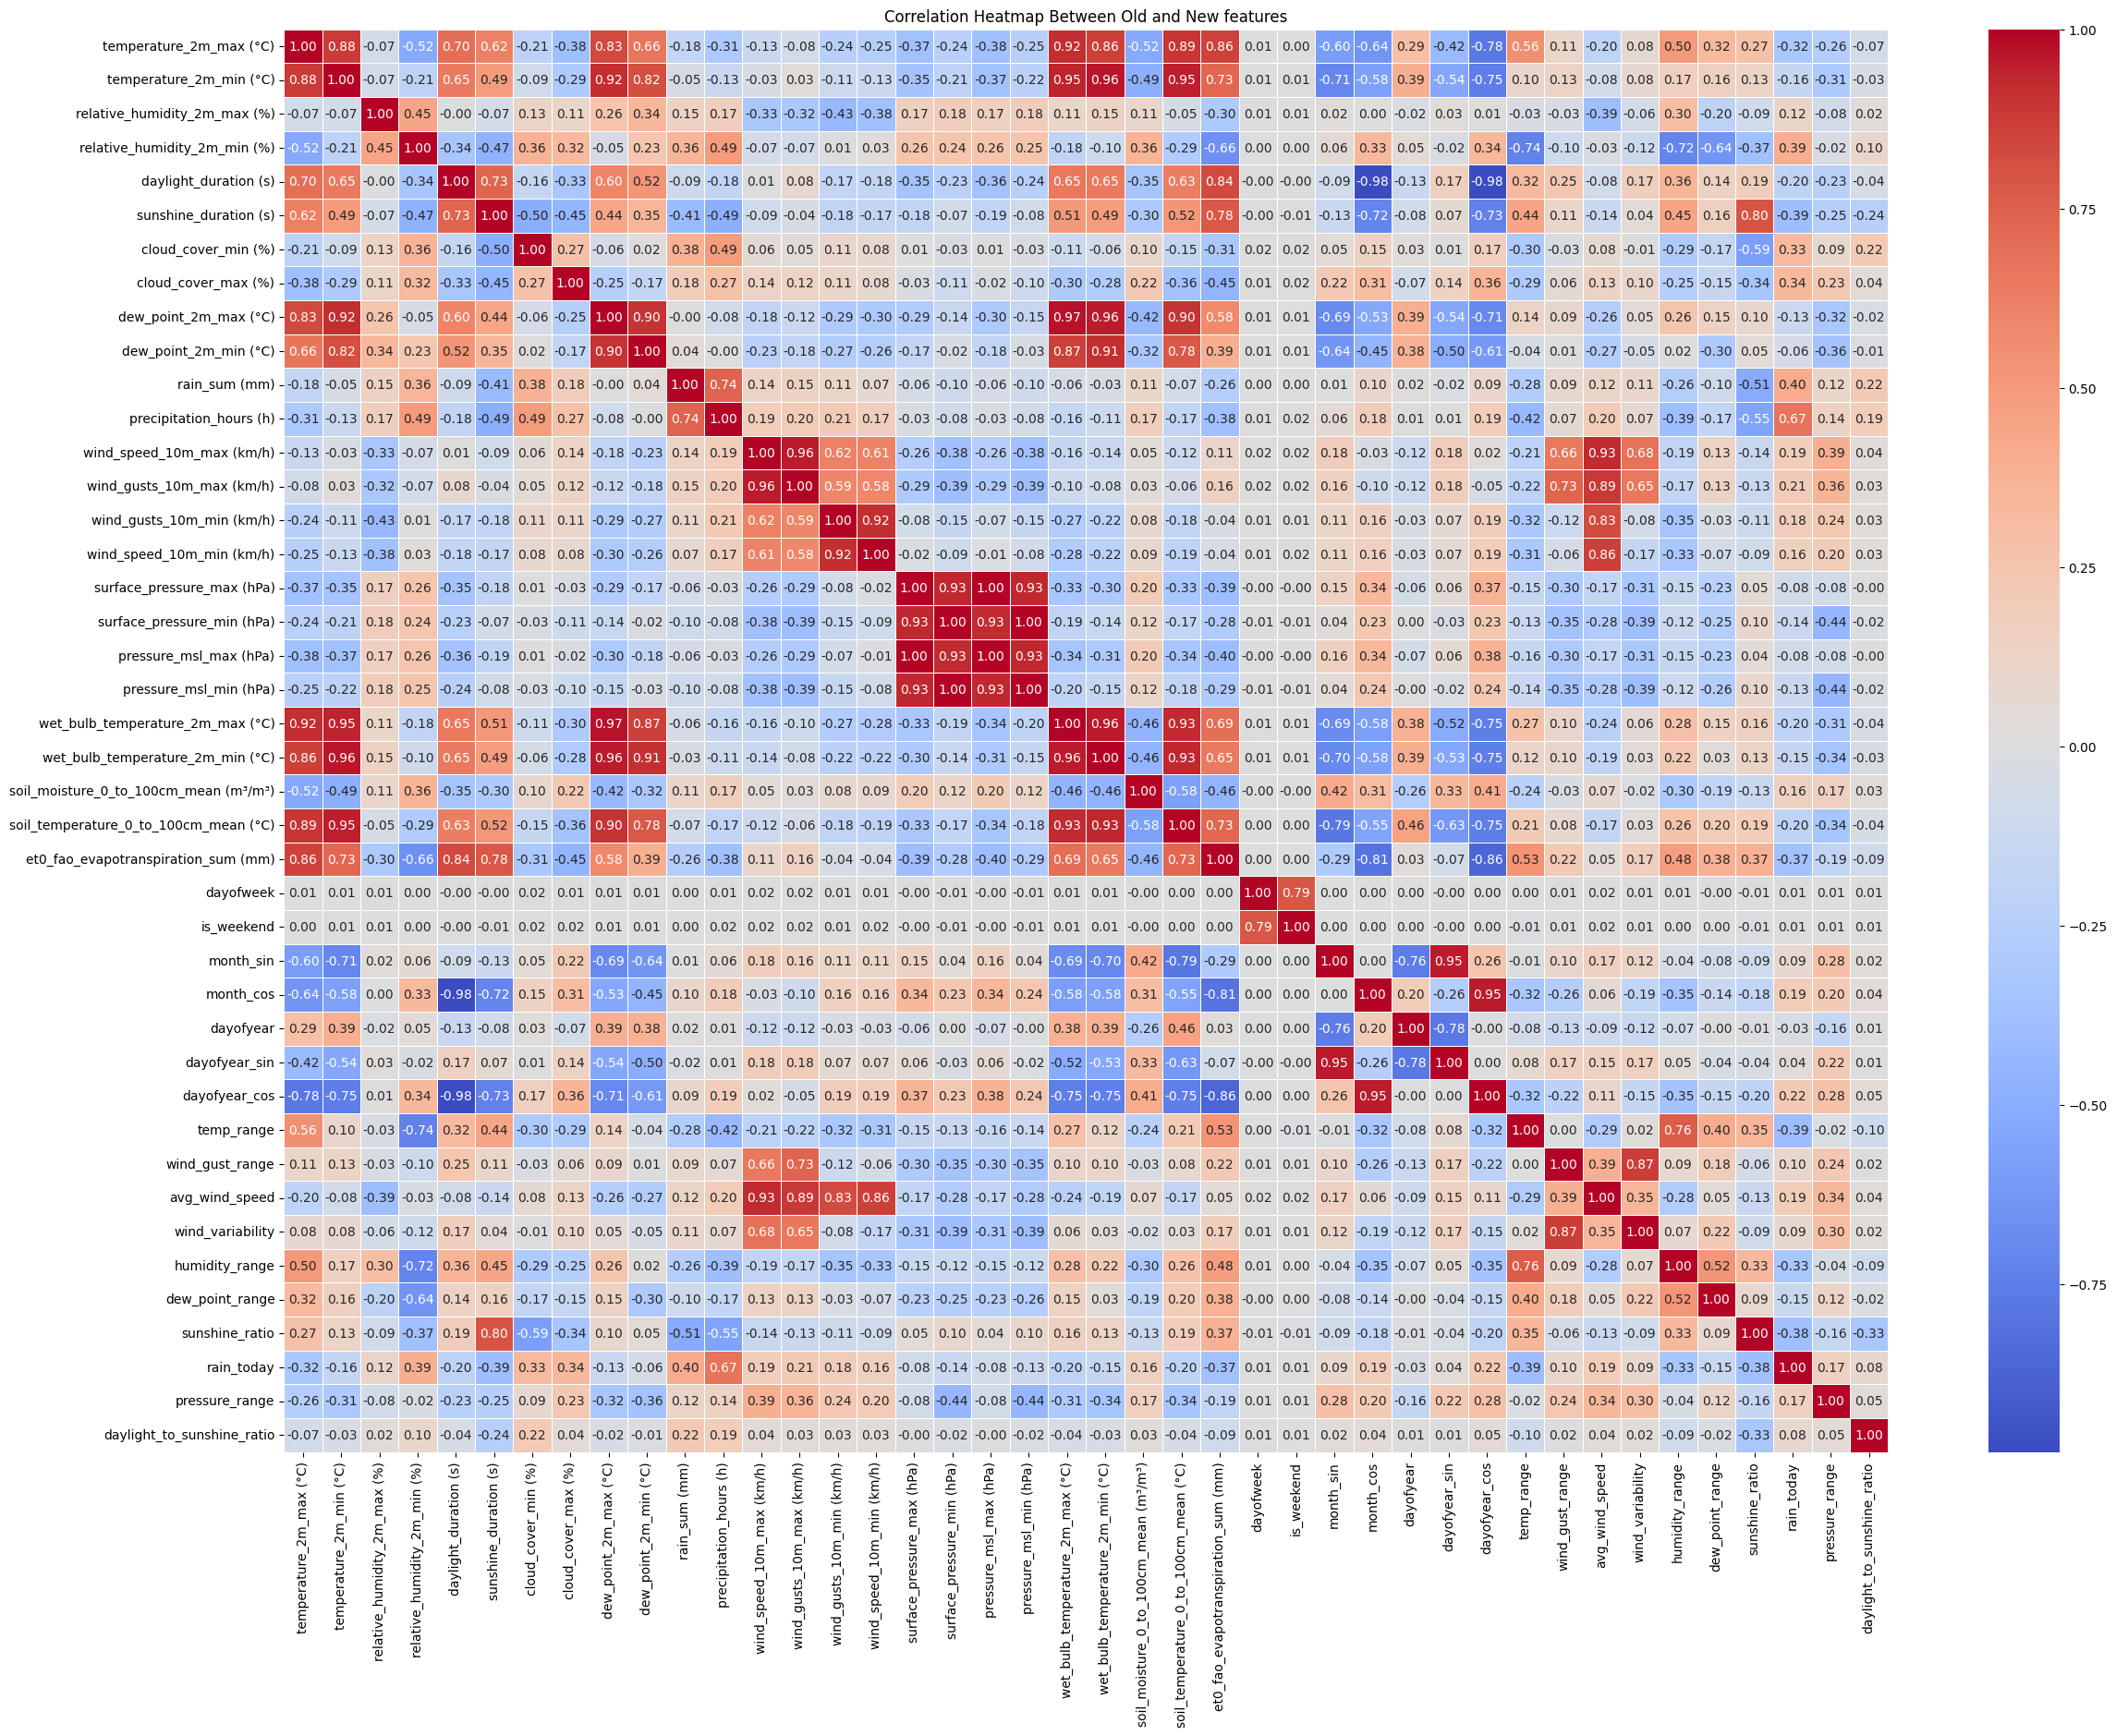

In [ ]:
corr_matrix = data2.corr()

# Display heatmap
plt.figure(figsize=(28, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Between Old and New features")
plt.show()

**Conclusion :** To avoid the highly correlation between the variables, we have to drop some variables:

- The dew_point_max variable because it's highly correlated with 5 features

- The wind_speed_max because it's strongly correlated with 2 features

- The Surface_pressure features because they have a strong correlation with the MSL features

- The wet_bulb_temperature features because each one of them is highly correlated with 5 other features

- The soil_temperature feature because it's highly correlated with 5 features

**3. Checking for missing values**

In [28]:
print(df1.isnull().sum())

date                                     0
year                                     0
month                                    0
day                                      0
temperature_2m_max (°C)                  0
temperature_2m_min (°C)                  0
relative_humidity_2m_max (%)             0
relative_humidity_2m_min (%)             0
daylight_duration (s)                    0
sunshine_duration (s)                    0
cloud_cover_min (%)                      0
cloud_cover_max (%)                      0
dew_point_2m_max (°C)                    0
dew_point_2m_min (°C)                    0
rain_sum (mm)                            0
precipitation_hours (h)                  0
wind_speed_10m_max (km/h)                0
wind_gusts_10m_max (km/h)                0
wind_gusts_10m_min (km/h)                0
wind_speed_10m_min (km/h)                0
surface_pressure_max (hPa)               0
surface_pressure_min (hPa)               0
pressure_msl_max (hPa)                   0
pressure_ms

**4. Re-ordering the columns**

In [ ]:
desired_order = [
    'date', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'dayofyear', 'month_sin', 'month_cos',
    'dayofyear_sin', 'dayofyear_cos',
    
    'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temp_range',
    'dew_point_2m_max (°C)', 'dew_point_2m_min (°C)', 'dew_point_range',
    'wet_bulb_temperature_2m_max (°C)', 'wet_bulb_temperature_2m_min (°C)',
    
    'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'humidity_range',
    
    'daylight_duration (s)', 'sunshine_duration (s)', 'sunshine_ratio', 'daylight_to_sunshine_ratio',
    
    'cloud_cover_min (%)', 'cloud_cover_max (%)',
    
    'rain_sum (mm)', 'precipitation_hours (h)', 'rain_today',
    
    'wind_speed_10m_max (km/h)', 'wind_speed_10m_min (km/h)', 'avg_wind_speed',
    'wind_gusts_10m_max (km/h)', 'wind_gusts_10m_min (km/h)', 'wind_gust_range', 'wind_variability',
    
    'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)',
    'pressure_msl_max (hPa)', 'pressure_msl_min (hPa)', 'pressure_range',
    
    'soil_moisture_0_to_100cm_mean (m³/m³)', 'soil_temperature_0_to_100cm_mean (°C)',
    
    'et0_fao_evapotranspiration_sum (mm)',
    
    'weather_condition'  # target at the end
]

# Reorder the DataFrame
df1 = df1[desired_order]

**5. Dropping the highly correlated features and saving the new dataframe**

In [ ]:
data3 = df1.copy()
cols_to_drop = [
    'dew_point_2m_max (°C)',
    'wind_speed_10m_max (km/h)',
    'surface_pressure_max (hPa)',
    'surface_pressure_min (hPa)',
    'wet_bulb_temperature_2m_max (°C)',
    'wet_bulb_temperature_2m_min (°C)',
    'soil_temperature_0_to_100cm_mean (°C)'
]

# Drop the columns
data3.drop(columns=cols_to_drop, inplace=True)
data3.to_csv('final_cleaned_weather_data_monastir.csv', index=False)

# **Step 5 : Feature importance + creating lag features + creating rolling windows**

In [32]:
df= pd.read_csv("final_cleaned_weather_data_monastir.csv")
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,wind_gusts_10m_max (km/h),wind_gusts_10m_min (km/h),wind_gust_range,wind_variability,pressure_msl_max (hPa),pressure_msl_min (hPa),pressure_range,soil_moisture_0_to_100cm_mean (m³/m³),et0_fao_evapotranspiration_sum (mm),weather_condition
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,32.4,6.5,25.9,13.5,1016.0,1012.9,3.1,0.290,3.72,Cloudy ☁️
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,31.3,5.8,25.5,11.2,1019.4,1015.2,4.2,0.285,3.59,Moderate Rain 🌧
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,33.8,9.0,24.8,14.8,1020.9,1018.4,2.5,0.280,3.44,Light Rain 🌦
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,38.5,1.8,36.7,17.1,1021.3,1019.6,1.7,0.282,3.50,Heavy Drizzle 🌧
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,38.9,1.8,37.1,18.1,1021.2,1017.6,3.5,0.277,4.09,Cloudy ☁️


Preparing data for feature importance analysis...
Analyzing 38 features...
Target classes: ['Clear Sky ☀️', 'Cloudy ☁️', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧', 'Light Drizzle 🌦', 'Light Rain 🌦', 'Mainly Clear 🌤', 'Moderate Drizzle 🌧', 'Moderate Rain 🌧', 'Partly Cloudy ⛅']

1. Computing Random Forest feature importance...
2. Computing Extra Trees feature importance...
3. Computing Mutual Information scores...
4. Computing F-statistics...
5. Computing correlation analysis...
6. Combining all importance measures...
7. Creating visualizations...


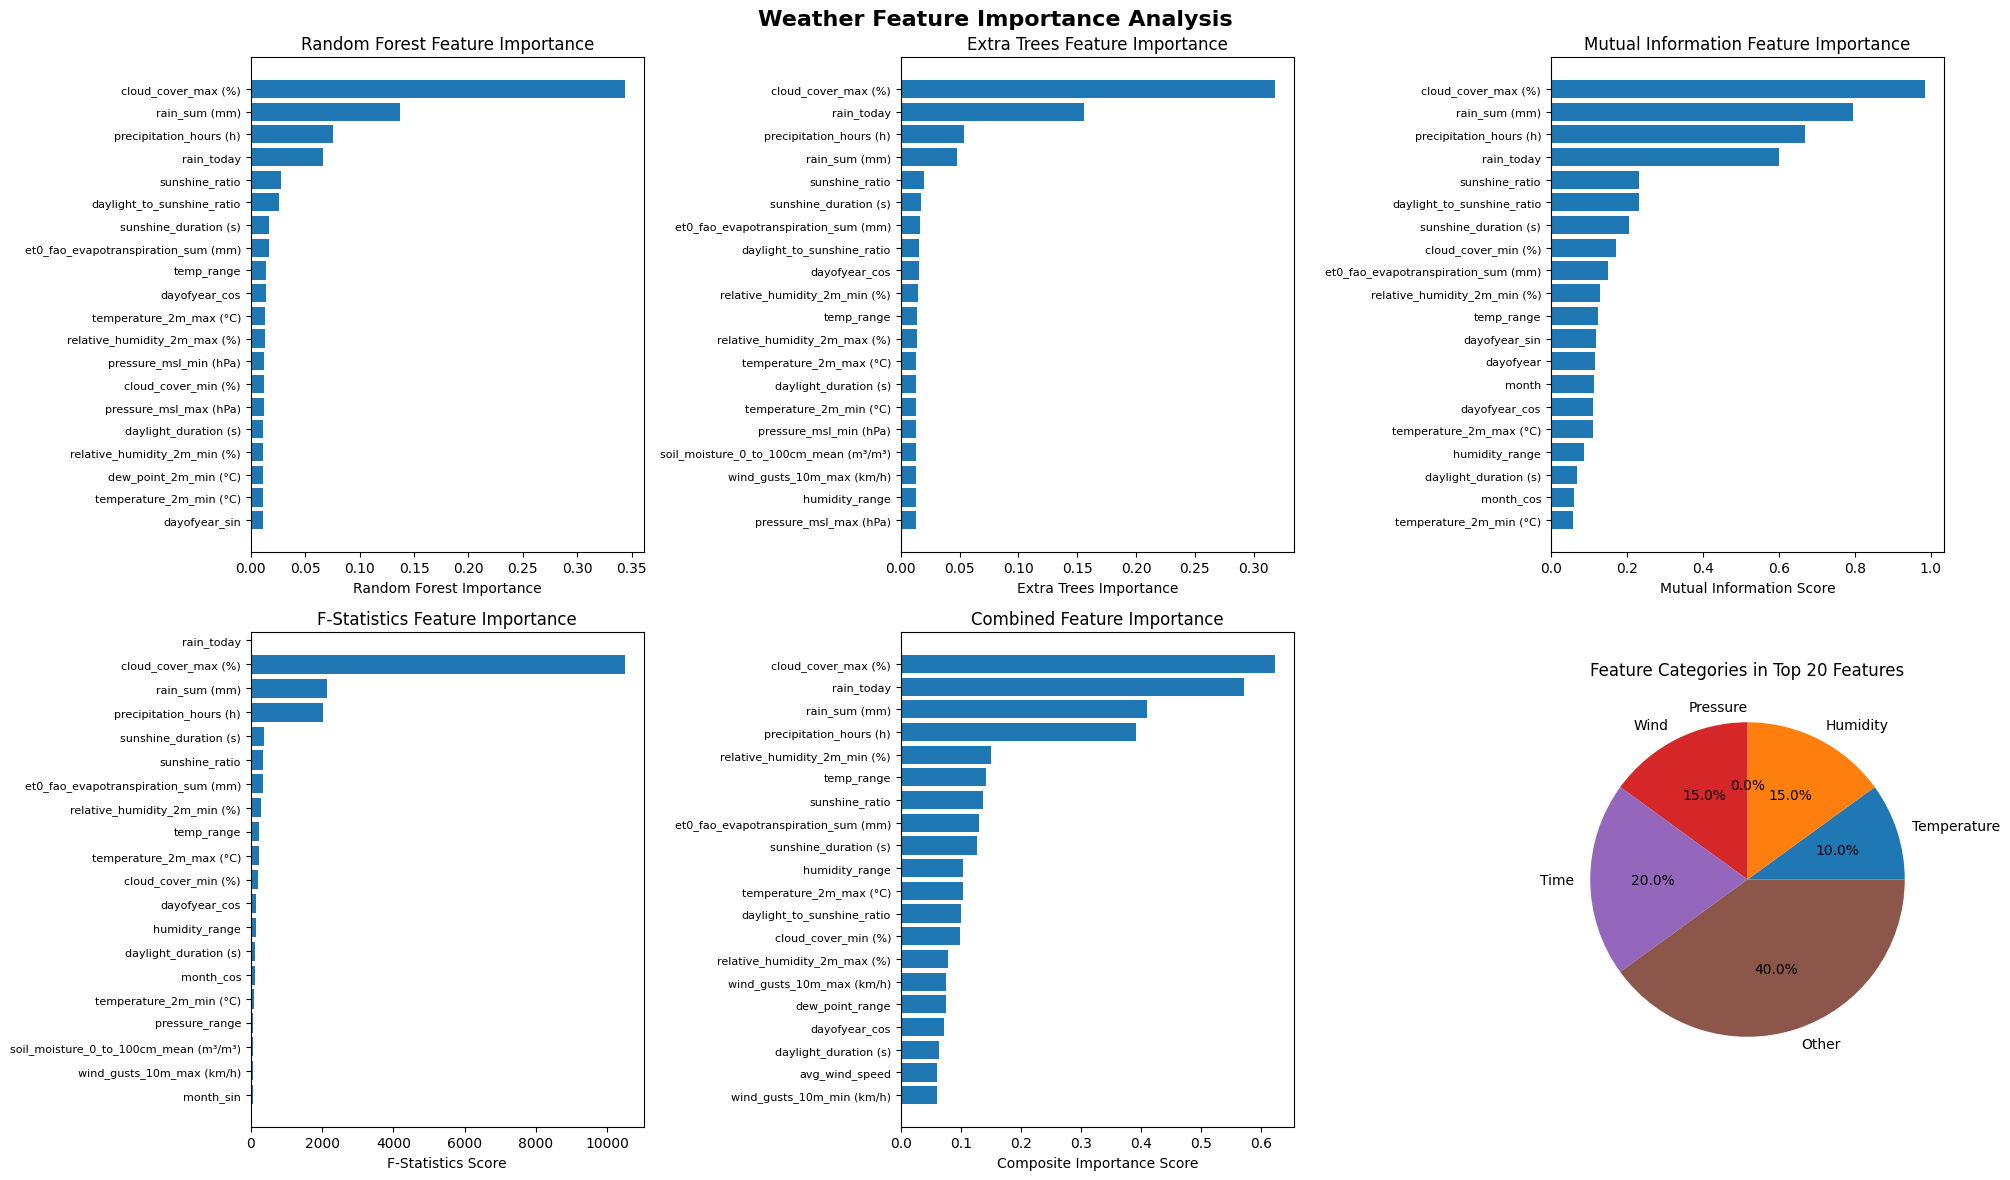


WEATHER FEATURE IMPORTANCE ANALYSIS SUMMARY

Top 15 Most Important Features:
--------------------------------------------------
cloud_cover_max (%)            | Composite Score: 0.6244
rain_today                     | Composite Score: 0.5727
rain_sum (mm)                  | Composite Score: 0.4101
precipitation_hours (h)        | Composite Score: 0.3921
relative_humidity_2m_min (%)   | Composite Score: 0.1497
temp_range                     | Composite Score: 0.1421
sunshine_ratio                 | Composite Score: 0.1372
et0_fao_evapotranspiration_sum (mm) | Composite Score: 0.1305
sunshine_duration (s)          | Composite Score: 0.1267
humidity_range                 | Composite Score: 0.1042
temperature_2m_max (°C)        | Composite Score: 0.1035
daylight_to_sunshine_ratio     | Composite Score: 0.1005
cloud_cover_min (%)            | Composite Score: 0.0985
relative_humidity_2m_max (%)   | Composite Score: 0.0786
wind_gusts_10m_max (km/h)      | Composite Score: 0.0750

Feature Ca

In [ ]:
def analyze_weather_feature_importance(df, target_col='weather_condition', top_k=20):
    
    # Prepare data
    print("Preparing data for feature importance analysis...")
    df_analysis = df.copy()
    
    # Handle date column
    if 'date' in df_analysis.columns:
        df_analysis = df_analysis.drop('date', axis=1)
    
    # Separate features and target
    if target_col not in df_analysis.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe")
    
    X = df_analysis.drop(target_col, axis=1)
    y = df_analysis[target_col]
    
    # Encode target if it's categorical
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Handle categorical features
    categorical_features = []
    numerical_features = []
    
    for col in X.columns:
        if X[col].dtype in ['object', 'category']:
            categorical_features.append(col)
        else:
            numerical_features.append(col)
    
    # Encode categorical features
    X_processed = X.copy()
    for col in categorical_features:
        if col in X_processed.columns:
            le_feat = LabelEncoder()
            X_processed[col] = le_feat.fit_transform(X_processed[col].astype(str))
    
    # Handle missing values
    X_processed = X_processed.fillna(X_processed.mean())
    
    print(f"Analyzing {len(X_processed.columns)} features...")
    print(f"Target classes: {list(le.classes_)}")
    
    # Split data for model-based importance
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    print("\n1. Computing Random Forest feature importance...")
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    rf_importance = pd.DataFrame({
        'feature': X_processed.columns,
        'rf_importance': rf.feature_importances_
    }).sort_values('rf_importance', ascending=False)
    
    print("2. Computing Extra Trees feature importance...")
    
    et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    et.fit(X_train, y_train)
    
    et_importance = pd.DataFrame({
        'feature': X_processed.columns,
        'et_importance': et.feature_importances_
    }).sort_values('et_importance', ascending=False)
    
    print("3. Computing Mutual Information scores...")
    
    mi_scores = mutual_info_classif(X_processed, y_encoded, random_state=42)
    mi_importance = pd.DataFrame({
        'feature': X_processed.columns,
        'mi_score': mi_scores
    }).sort_values('mi_score', ascending=False)
    
    print("4. Computing F-statistics...")
    
    f_scores, _ = f_classif(X_processed, y_encoded)
    f_importance = pd.DataFrame({
        'feature': X_processed.columns,
        'f_score': f_scores
    }).sort_values('f_score', ascending=False)
    
    print("5. Computing correlation analysis...")
    
    # For numerical features, compute correlation with target
    correlation_scores = []
    
    for col in numerical_features:
        if col in X_processed.columns:
            # Compute correlation between feature and encoded target
            try:
                corr_pearson, _ = pearsonr(X_processed[col], y_encoded)
                corr_spearman, _ = spearmanr(X_processed[col], y_encoded)
                correlation_scores.append({
                    'feature': col,
                    'pearson_corr': abs(corr_pearson),
                    'spearman_corr': abs(corr_spearman)
                })
            except:
                correlation_scores.append({
                    'feature': col,
                    'pearson_corr': 0,
                    'spearman_corr': 0
                })
    
    correlation_df = pd.DataFrame(correlation_scores)
    if len(correlation_df) > 0:
        correlation_df = correlation_df.sort_values('pearson_corr', ascending=False)
    
    print("6. Combining all importance measures...")
    
    # Merge all importance scores
    combined_importance = rf_importance.copy()
    combined_importance = combined_importance.merge(et_importance, on='feature', how='left')
    combined_importance = combined_importance.merge(mi_importance, on='feature', how='left')
    combined_importance = combined_importance.merge(f_importance, on='feature', how='left')
    
    if len(correlation_df) > 0:
        combined_importance = combined_importance.merge(correlation_df, on='feature', how='left')
        combined_importance['pearson_corr'] = combined_importance['pearson_corr'].fillna(0)
        combined_importance['spearman_corr'] = combined_importance['spearman_corr'].fillna(0)
    else:
        combined_importance['pearson_corr'] = 0
        combined_importance['spearman_corr'] = 0
    
    # Normalize all scores to 0-1 range
    for score_col in ['rf_importance', 'et_importance', 'mi_score', 'f_score', 'pearson_corr']:
        if score_col in combined_importance.columns:
            max_val = combined_importance[score_col].max()
            if max_val > 0:
                combined_importance[f'{score_col}_norm'] = combined_importance[score_col] / max_val
            else:
                combined_importance[f'{score_col}_norm'] = 0
    
    # Calculate composite score (average of normalized scores)
    score_columns = [col for col in combined_importance.columns if col.endswith('_norm')]
    combined_importance['composite_score'] = combined_importance[score_columns].mean(axis=1)
    combined_importance = combined_importance.sort_values('composite_score', ascending=False)
    
    print("7. Creating visualizations...")
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Weather Feature Importance Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Random Forest Importance
    top_rf = rf_importance.head(top_k)
    axes[0, 0].barh(range(len(top_rf)), top_rf['rf_importance'])
    axes[0, 0].set_yticks(range(len(top_rf)))
    axes[0, 0].set_yticklabels(top_rf['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Random Forest Importance')
    axes[0, 0].set_title('Random Forest Feature Importance')
    axes[0, 0].invert_yaxis()
    
    # Plot 2: Extra Trees Importance
    top_et = et_importance.head(top_k)
    axes[0, 1].barh(range(len(top_et)), top_et['et_importance'])
    axes[0, 1].set_yticks(range(len(top_et)))
    axes[0, 1].set_yticklabels(top_et['feature'], fontsize=8)
    axes[0, 1].set_xlabel('Extra Trees Importance')
    axes[0, 1].set_title('Extra Trees Feature Importance')
    axes[0, 1].invert_yaxis()
    
    # Plot 3: Mutual Information
    top_mi = mi_importance.head(top_k)
    axes[0, 2].barh(range(len(top_mi)), top_mi['mi_score'])
    axes[0, 2].set_yticks(range(len(top_mi)))
    axes[0, 2].set_yticklabels(top_mi['feature'], fontsize=8)
    axes[0, 2].set_xlabel('Mutual Information Score')
    axes[0, 2].set_title('Mutual Information Feature Importance')
    axes[0, 2].invert_yaxis()
    
    # Plot 4: F-Statistics
    top_f = f_importance.head(top_k)
    axes[1, 0].barh(range(len(top_f)), top_f['f_score'])
    axes[1, 0].set_yticks(range(len(top_f)))
    axes[1, 0].set_yticklabels(top_f['feature'], fontsize=8)
    axes[1, 0].set_xlabel('F-Statistics Score')
    axes[1, 0].set_title('F-Statistics Feature Importance')
    axes[1, 0].invert_yaxis()
    
    # Plot 5: Composite Score
    top_composite = combined_importance.head(top_k)
    axes[1, 1].barh(range(len(top_composite)), top_composite['composite_score'])
    axes[1, 1].set_yticks(range(len(top_composite)))
    axes[1, 1].set_yticklabels(top_composite['feature'], fontsize=8)
    axes[1, 1].set_xlabel('Composite Importance Score')
    axes[1, 1].set_title('Combined Feature Importance')
    axes[1, 1].invert_yaxis()
    
    # Plot 6: Feature Categories Distribution
    feature_categories = {
        'Temperature': [col for col in X.columns if 'temp' in col.lower()],
        'Humidity': [col for col in X.columns if 'humidity' in col.lower()],
        'Pressure': [col for col in X.columns if 'pressure' in col.lower()],
        'Wind': [col for col in X.columns if 'wind' in col.lower()],
        'Time': [col for col in X.columns if any(t in col.lower() for t in ['day', 'month', 'year', 'weekend'])],
        'Other': []
    }
    
    # Categorize remaining features
    categorized = set()
    for cat_features in feature_categories.values():
        categorized.update(cat_features)
    
    feature_categories['Other'] = [col for col in X.columns if col not in categorized]
    
    # Calculate average importance by category
    category_importance = {}
    top_features = set(combined_importance.head(top_k)['feature'])
    
    for category, features in feature_categories.items():
        if features:
            category_features_in_top = [f for f in features if f in top_features]
            category_importance[category] = len(category_features_in_top)
    
    if category_importance:
        categories = list(category_importance.keys())
        importances = list(category_importance.values())
        axes[1, 2].pie(importances, labels=categories, autopct='%1.1f%%')
        axes[1, 2].set_title(f'Feature Categories in Top {top_k} Features')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print("WEATHER FEATURE IMPORTANCE ANALYSIS SUMMARY")
    print(f"{'='*60}")
    
    print(f"\nTop {min(15, len(combined_importance))} Most Important Features:")
    print("-" * 50)
    for idx, row in combined_importance.head(15).iterrows():
        print(f"{row['feature']:<30} | Composite Score: {row['composite_score']:.4f}")
    
    print(f"\nFeature Category Analysis:")
    print("-" * 30)
    for category, count in category_importance.items():
        if count > 0:
            print(f"{category:<15}: {count} features in top {top_k}")
    
    print(f"\nModel Performance with Top Features:")
    print("-" * 40)
    print(f"Random Forest Accuracy: {rf.score(X_test, y_test):.4f}")
    print(f"Extra Trees Accuracy: {et.score(X_test, y_test):.4f}")
    
    print(f"\n{'='*60}")
    print("RECOMMENDATIONS FOR FEATURE ENGINEERING")
    print(f"{'='*60}")
    
    top_features = combined_importance.head(20)['feature'].tolist()
    
    print(f"\n✅ PRIORITY FEATURES FOR LAGGED/ROLLING STATISTICS:")
    print("-" * 55)
    priority_features = []
    
    for feature in top_features:
        if any(keyword in feature.lower() for keyword in ['temp', 'humidity', 'pressure', 'wind']):
            priority_features.append(feature)
            print(f"  • {feature}")
    
    print(f"\n💡 FEATURE ENGINEERING STRATEGY:")
    print("-" * 35)
    print(f"  1. Focus lagged features on: {', '.join(priority_features[:5])}")
    print(f"  2. Create rolling statistics for: {', '.join(priority_features[:3])}")
    print(f"  3. Consider dropping low-importance features (composite score < 0.1)")
    
    low_importance = combined_importance[combined_importance['composite_score'] < 0.1]
    if len(low_importance) > 0:
        print(f"  4. {len(low_importance)} features have very low importance - consider removing")
    
    # Return results
    results = {
        'combined_importance': combined_importance,
        'rf_importance': rf_importance,
        'et_importance': et_importance,
        'mi_importance': mi_importance,
        'f_importance': f_importance,
        'top_features': top_features,
        'priority_features': priority_features,
        'low_importance_features': low_importance['feature'].tolist() if len(low_importance) > 0 else [],
        'rf_model': rf,
        'et_model': et,
        'label_encoder': le
    }
    
    return results


# Load your weather data
df = pd.read_csv("final_cleaned_weather_data_monastir.csv")

# Run comprehensive feature importance analysis
results = analyze_weather_feature_importance(df, target_col='weather_condition', top_k=20)

# Get the most important features for your LSTM engineering
top_features = results['top_features']
priority_features = results['priority_features']

# Use these results to focus your feature engineering efforts
print("Focus your lagged/rolling features on these variables:")
for feature in priority_features[:10]:
    print(f"  - {feature}")

# Save results
results['combined_importance'].to_csv('feature_importance_analysis.csv', index=False)


In [ ]:
def create_targeted_weather_features(df):
    
    df_enhanced = df.copy()
    
    # Ensure date is datetime for proper sorting
    if 'date' in df_enhanced.columns:
        df_enhanced['date'] = pd.to_datetime(df_enhanced['date'])
        df_enhanced = df_enhanced.sort_values('date').reset_index(drop=True)
    
    print("Creating targeted weather features based on importance analysis...")
    
    print("1. Engineering Tier 1 (Core Weather State) features...")
    
    tier1_features = [
        'cloud_cover_max (%)',
        'rain_sum (mm)', 
        'precipitation_hours (h)',
        'cloud_cover_min (%)'
    ]
    
    # Focus heavy engineering on these top features
    for feature in tier1_features:
        if feature in df_enhanced.columns:
            feature_clean = feature.replace(' ', '_').replace('(%)', '').replace('(mm)', '').replace('(h)', '')
            
            # Lagged features (1-7 days) - weather persistence is crucial
            for lag in [1, 2, 3, 7]:
                df_enhanced[f'{feature_clean}_lag_{lag}'] = df_enhanced[feature].shift(lag)
            
            # Rolling statistics (key for weather patterns)
            for window in [3, 7, 14]:
                df_enhanced[f'{feature_clean}_rolling_mean_{window}d'] = df_enhanced[feature].rolling(window, min_periods=1).mean()
                df_enhanced[f'{feature_clean}_rolling_std_{window}d'] = df_enhanced[feature].rolling(window, min_periods=1).std()
                df_enhanced[f'{feature_clean}_rolling_max_{window}d'] = df_enhanced[feature].rolling(window, min_periods=1).max()
            
            # Trend features
            df_enhanced[f'{feature_clean}_3day_trend'] = df_enhanced[feature].diff(3)
            df_enhanced[f'{feature_clean}_7day_trend'] = df_enhanced[feature].diff(7)
            
            # Exponential weighted moving average
            df_enhanced[f'{feature_clean}_ewm_3d'] = df_enhanced[feature].ewm(span=3, min_periods=1).mean()
            df_enhanced[f'{feature_clean}_ewm_7d'] = df_enhanced[feature].ewm(span=7, min_periods=1).mean()
    
    # Special handling for rain_today (binary feature)
    if 'rain_today' in df_enhanced.columns:
        # Rain persistence patterns
        df_enhanced['rain_today_lag_1'] = df_enhanced['rain_today'].shift(1)
        df_enhanced['rain_today_lag_2'] = df_enhanced['rain_today'].shift(2)
        df_enhanced['rain_today_lag_3'] = df_enhanced['rain_today'].shift(3)
        
        # Rolling rain frequency
        df_enhanced['rain_frequency_7d'] = df_enhanced['rain_today'].rolling(7, min_periods=1).mean()
        df_enhanced['rain_frequency_14d'] = df_enhanced['rain_today'].rolling(14, min_periods=1).mean()
        
        # Consecutive rain days
        df_enhanced['consecutive_rain_days'] = (
            df_enhanced['rain_today'].groupby(
                (df_enhanced['rain_today'] != df_enhanced['rain_today'].shift()).cumsum()
            ).cumsum()
        )
        
        # Days since last rain
        rain_dates = df_enhanced[df_enhanced['rain_today'] == 1].index
        df_enhanced['days_since_rain'] = np.nan
        for i in df_enhanced.index:
            prev_rain = rain_dates[rain_dates < i]
            if len(prev_rain) > 0:
                df_enhanced.loc[i, 'days_since_rain'] = i - prev_rain.max()
        df_enhanced['days_since_rain'] = df_enhanced['days_since_rain'].fillna(30)  # Cap at 30 days
    
    print("2. Engineering Tier 2 (Physical Variables) features...")
    
    tier2_features = [
        'temp_range',
        'relative_humidity_2m_min (%)',
        'temperature_2m_max (°C)',
        'humidity_range',
        'relative_humidity_2m_max (%)'
    ]
    
    # Lighter engineering for these features
    for feature in tier2_features:
        if feature in df_enhanced.columns:
            feature_clean = feature.replace(' ', '_').replace('(%)', '').replace('(°C)', '')
            
            # Key lagged features only
            for lag in [1, 3, 7]:
                df_enhanced[f'{feature_clean}_lag_{lag}'] = df_enhanced[feature].shift(lag)
            
            # Essential rolling statistics
            df_enhanced[f'{feature_clean}_rolling_mean_7d'] = df_enhanced[feature].rolling(7, min_periods=1).mean()
            df_enhanced[f'{feature_clean}_rolling_std_7d'] = df_enhanced[feature].rolling(7, min_periods=1).std()
            
            # Trend features
            df_enhanced[f'{feature_clean}_7day_trend'] = df_enhanced[feature].diff(7)
    
    print("3. Creating interaction features...")
    
    # High-impact feature interactions
    if 'cloud_cover_max (%)' in df_enhanced.columns and 'rain_sum (mm)' in df_enhanced.columns:
        df_enhanced['cloud_rain_interaction'] = df_enhanced['cloud_cover_max (%)'] * df_enhanced['rain_sum (mm)']
    
    if 'temp_range' in df_enhanced.columns and 'relative_humidity_2m_min (%)' in df_enhanced.columns:
        df_enhanced['temp_humidity_interaction'] = df_enhanced['temp_range'] * df_enhanced['relative_humidity_2m_min (%)']
    
    if 'precipitation_hours (h)' in df_enhanced.columns and 'cloud_cover_max (%)' in df_enhanced.columns:
        df_enhanced['precip_cloud_interaction'] = df_enhanced['precipitation_hours (h)'] * df_enhanced['cloud_cover_max (%)']
    
    print("4. Creating weather pattern features...")
    
    # Weather stability indicators
    if 'cloud_cover_max (%)' in df_enhanced.columns:
        df_enhanced['cloud_volatility_7d'] = df_enhanced['cloud_cover_max (%)'].rolling(7, min_periods=1).std()
    
    if 'rain_sum (mm)' in df_enhanced.columns:
        df_enhanced['rain_volatility_7d'] = df_enhanced['rain_sum (mm)'].rolling(7, min_periods=1).std()
    
    # Seasonal anomalies for top features
    if 'temperature_2m_max (°C)' in df_enhanced.columns and 'dayofyear' in df_enhanced.columns:
        df_enhanced['temp_seasonal_anomaly'] = (
            df_enhanced['temperature_2m_max (°C)'] - 
            df_enhanced.groupby('dayofyear')['temperature_2m_max (°C)'].transform('mean')
        )
    
    print("5. Optimizing feature set...")
    
    # Identify and remove low-importance features (keeping time features)
    low_importance_features = [
        # Add your 27 low-importance features here (except time features)
        'et0_fao_evapotranspiration_sum (mm)',  # Remove if score < 0.1 and not in top tier
    ]
    
    # Remove low-importance features (but keep ALL time features)
    time_related_keywords = ['year', 'month', 'day', 'dayof', 'weekend', 'sin', 'cos']
    
    features_to_drop = []
    for feature in low_importance_features:
        if feature in df_enhanced.columns:
            # Don't drop if it's a time-related feature
            if not any(keyword in feature.lower() for keyword in time_related_keywords):
                features_to_drop.append(feature)
    
    if features_to_drop:
        print(f"Removing {len(features_to_drop)} low-importance non-temporal features...")
        df_enhanced = df_enhanced.drop(columns=features_to_drop)
    
    original_features = len(df.columns)
    final_features = len(df_enhanced.columns)
    new_features = final_features - original_features
    
    print(f"\n{'='*50}")
    print("TARGETED FEATURE ENGINEERING SUMMARY")
    print(f"{'='*50}")
    print(f"Original features: {original_features}")
    print(f"Final features: {final_features}")
    print(f"New features added: {new_features}")
    print(f"Features removed: {len(features_to_drop)}")
    
    # Feature breakdown
    tier1_count = len([col for col in df_enhanced.columns if any(t1 in col for t1 in ['cloud_cover', 'rain_', 'precipitation'])])
    tier2_count = len([col for col in df_enhanced.columns if any(t2 in col for t2 in ['temp_', 'humidity_'])])
    time_count = len([col for col in df_enhanced.columns if any(t in col.lower() for t in time_related_keywords)])
    
    print(f"\nFeature Categories:")
    print(f"  Weather State (Tier 1): ~{tier1_count} features")
    print(f"  Physical Variables (Tier 2): ~{tier2_count} features") 
    print(f"  Temporal Features: {time_count} features")
    print(f"  Other Features: {final_features - tier1_count - tier2_count - time_count} features")
    
    return df_enhanced


df_enhanced = create_targeted_weather_features(df1)
df_enhanced.to_csv('enhanced_dataset.csv', index=False)


Creating targeted weather features based on importance analysis...
1. Engineering Tier 1 (Core Weather State) features...
2. Engineering Tier 2 (Physical Variables) features...
3. Creating interaction features...
4. Creating weather pattern features...
5. Optimizing feature set...
Removing 1 low-importance non-temporal features...

TARGETED FEATURE ENGINEERING SUMMARY
Original features: 47
Final features: 157
New features added: 110
Features removed: 1

Feature Categories:
  Weather State (Tier 1): ~81 features
  Physical Variables (Tier 2): ~30 features
  Temporal Features: 31 features
  Other Features: 15 features


**Note: This is our final data that will be used in the modeling**